Wind Energy Modelling Bootcamp: Hands-on Python



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

Turbine Information:

Rated Power: 25 kW (7.7 m/s)

Cut in Speed: 2.5 m/s (0.855 kW)

Cut out Speed: 20 m/s (437 kW)

Blade length: 7.6 m, S_area = 181m^2

Hub Height = 16 m

In [ ]:
windspeed = pd.read_csv('Wind_Speed.csv')
windspeed

In [ ]:
ws = windspeed.iloc[:,4:5] # 4:5 is used so that you get the data as table instead of list
ws

In [ ]:
ws.describe()

In [ ]:
# To convert windspeed from km/hr to m/s
def meter_second(x):
  return x/3.6

In [ ]:
ad = 1.275 # Air density [kg/m^3]
BZ = 0.593 # Betz co-efficient
Area = 181 # Swept area [m^2]
nta_g = 0.8 # Generator efficiency

# To calculate power from windspeed
def wind_p(x):
  return (0.5 * ad * Area * x**3 * BZ * nta_g) / 1000 # Power output in kW

wind_power = wind_p(ws)
wind_power

In [ ]:
wind_power.rename(columns = {'WS10M': 'Power_Output (kW)'}, inplace = True)
wind_power

In [ ]:
power_cutin = wind_p(2.5)
power_cutout = wind_p(20)
# print(power_cutin)
# print(power_cutout)

In [ ]:
wind_power.loc [(wind_power['Power_Output (kW)'] >= 25) & (wind_power['Power_Output (kW)'] < 437)] = 25 # After  rated power is crossed, it would stay the same until it reached cutout power
wind_power.loc [(wind_power['Power_Output (kW)'] >= 437)] = 0 # No power above cut-out power
wind_power.loc [(wind_power['Power_Output (kW)'] <= 0.855)] = 0 # No power before cut-in power

Visualization Part

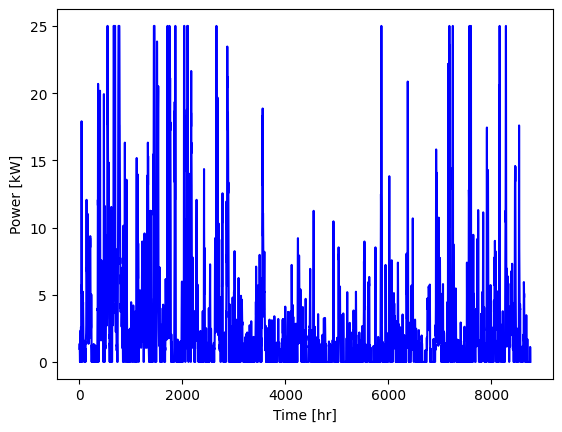

In [ ]:
plt.plot(wind_power, c='b')
plt.xlabel("Time [hr]")
plt.ylabel("Power [kW]")
plt.show()

In [ ]:
df = pd.concat([ws, wind_power] , axis = 1)
df.sort_values(by = ['WS10M'], ascending = True, inplace = True)
df.shape

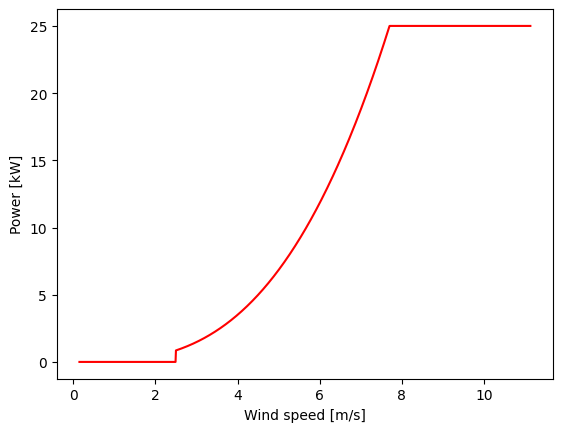

In [ ]:
plt.plot(df['WS10M'], df['Power_Output (kW)'], c='r')
plt.xlabel("Wind speed [m/s]")
plt.ylabel("Power [kW]")
plt.show()